In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(".."))

In [76]:
df = pd.read_csv("../results/experiments.csv")

num_cols = ["roc_auc", "f1", "accuracy"]

def fix_number(x):
    if pd.isna(x):
        return np.nan
    return float(str(x).replace(".", "")) / 1e16

for col in num_cols:
    df[col] = df[col].apply(fix_number)

print("Amostra após limpeza:")
display(df.head())

sns.set_theme(style="whitegrid")


Amostra após limpeza:


,model,scenario,smote,roc_auc,f1,accuracy,n_features,timestamp,type
0,XGBoost,sem_submodalidade,False,0.93,0.86,0.85,67,2026-04-09 21:01:38.604250,baseline
1,XGBoost,sem_submodalidade,True,0.93,0.87,0.85,67,2026-04-09 21:01:48.280996,baseline
2,XGBoost,submodalidade_agrupada,False,0.94,0.09,0.86,97,2026-04-09 21:01:52.986582,baseline
3,XGBoost,submodalidade_agrupada,True,0.09,0.88,0.87,97,2026-04-09 21:02:03.817310,baseline
4,XGBoost,submodalidade_engineered,False,0.93,0.86,0.85,67,2026-04-09 21:02:08.065526,baseline


### BASELINE - Gráfico por Submodalidade e Modelo

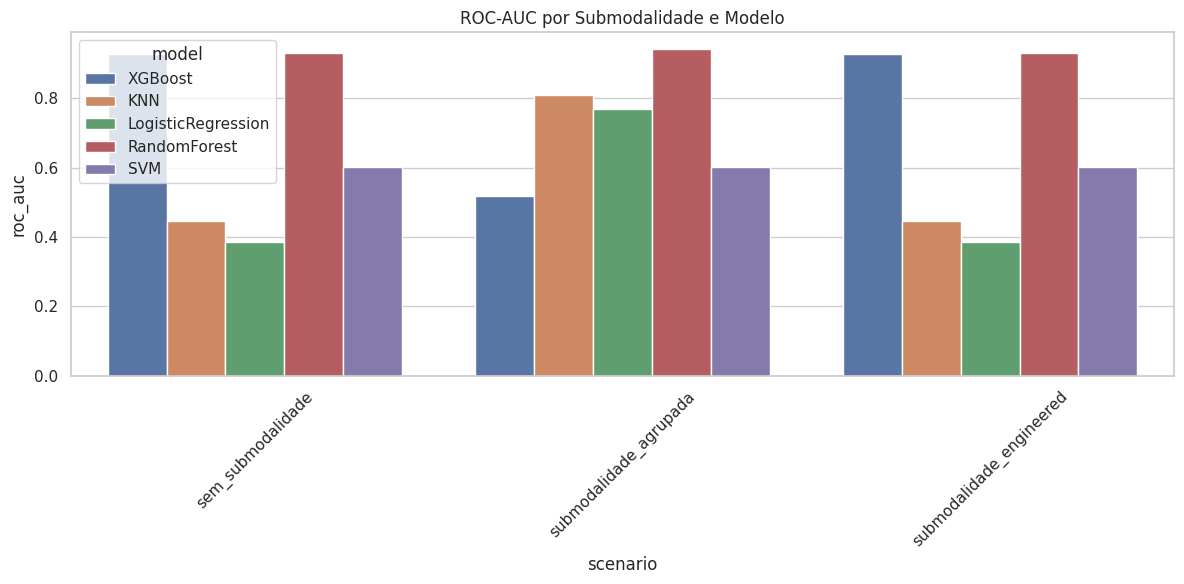

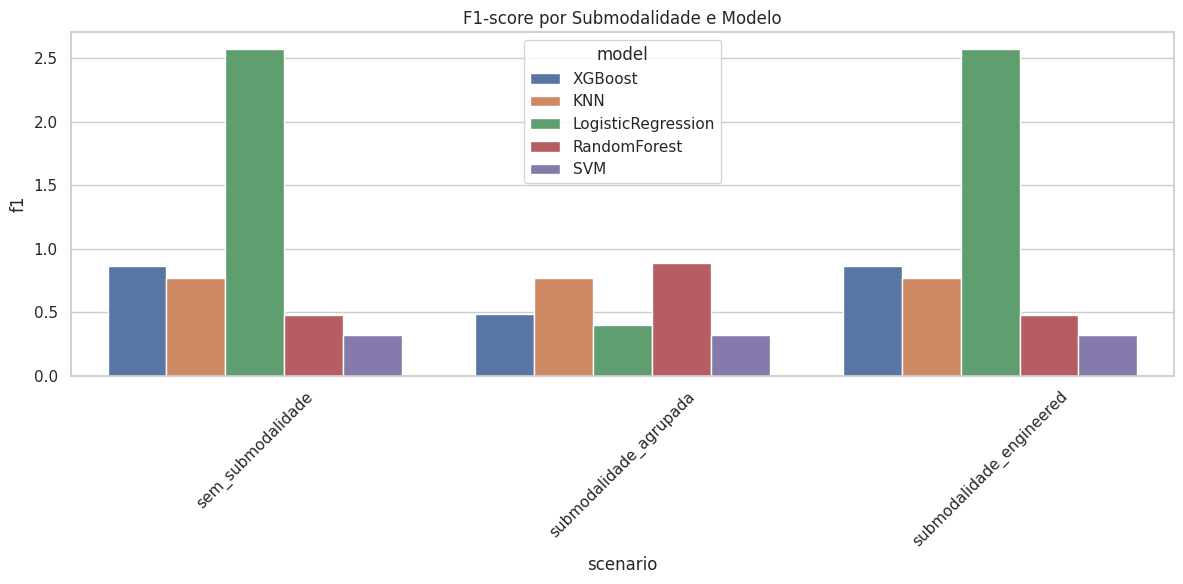

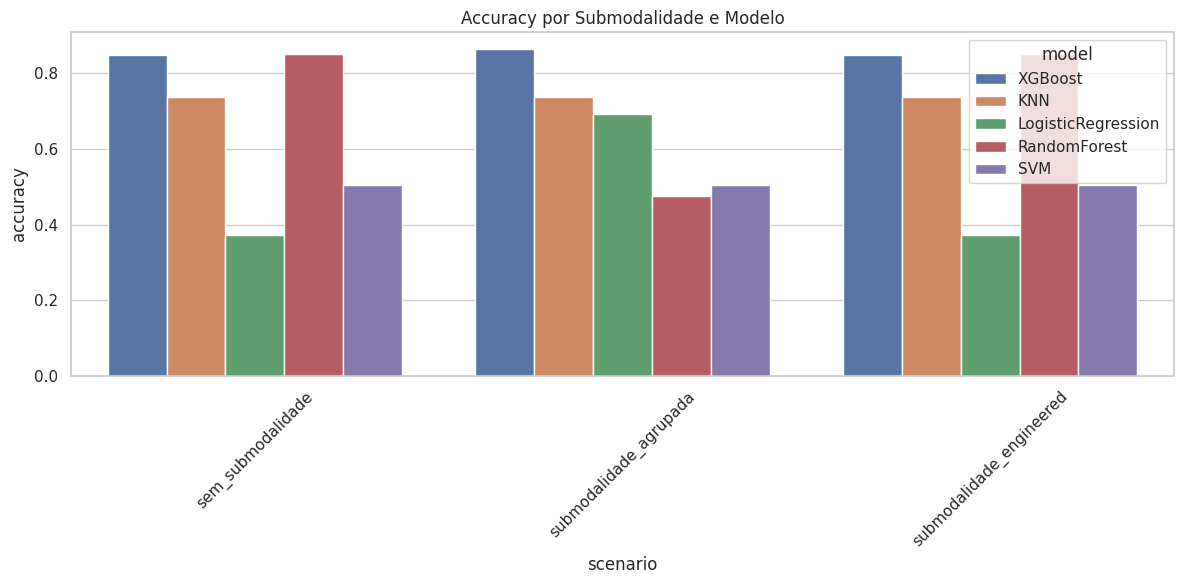

In [77]:
def plot_metric_by_scenario(metric, title):
    plt.figure(figsize=(12,6))
    sns.barplot(
        data=df,
        x="scenario",
        y=metric,
        hue="model",
        errorbar=None 
    )
    plt.xticks(rotation=45)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_metric_by_scenario("roc_auc", "ROC-AUC por Submodalidade e Modelo")
plot_metric_by_scenario("f1", "F1-score por Submodalidade e Modelo")
plot_metric_by_scenario("accuracy", "Accuracy por Submodalidade e Modelo")

### BASELINE -  Média Geral por Modelo

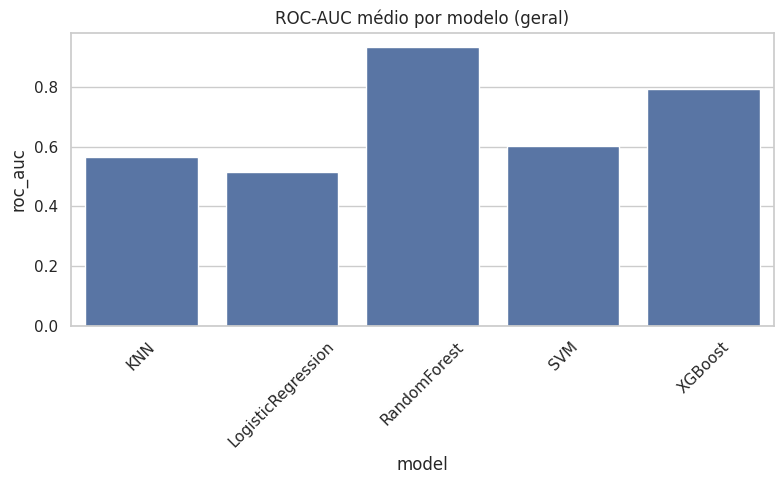

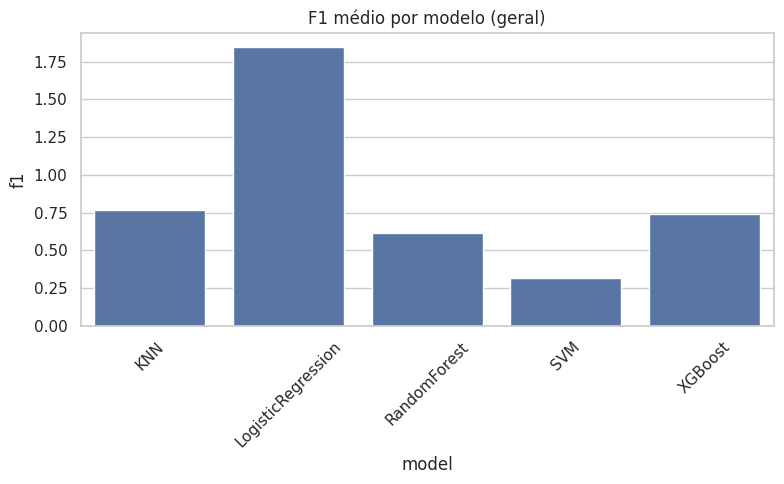

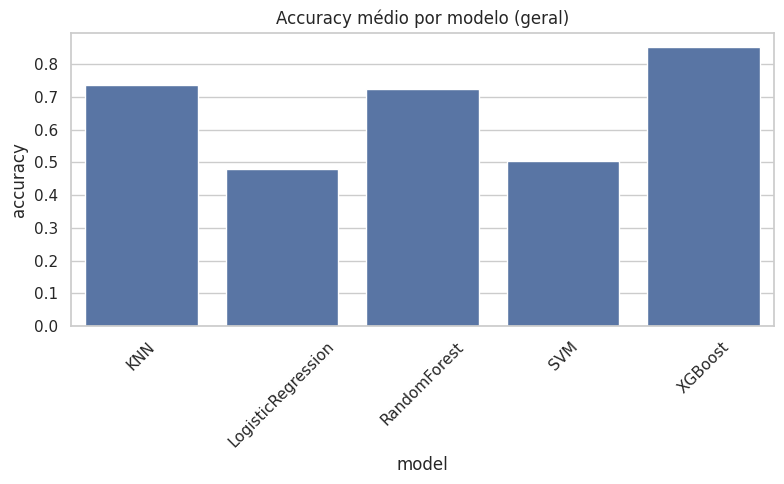

In [78]:
df_grouped = df.groupby("model")[num_cols].mean().reset_index()

def plot_general(metric, title):
    plt.figure(figsize=(8,5))
    sns.barplot(data=df_grouped, x="model", y=metric)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_general("roc_auc", "ROC-AUC médio por modelo (geral)")
plot_general("f1", "F1 médio por modelo (geral)")
plot_general("accuracy", "Accuracy médio por modelo (geral)")

### BASELINE - Heatmap Modelo x Submodalidade

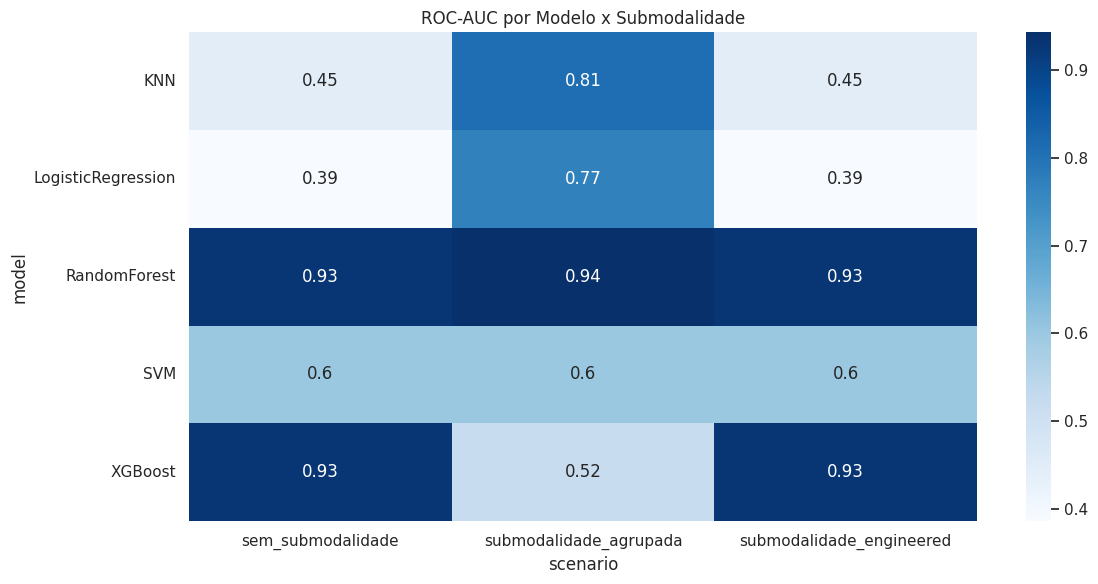

In [79]:
plt.figure(figsize=(12,6))

pivot = df.pivot_table(
    index="model",
    columns="scenario",
    values="roc_auc",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap="Blues")
plt.title("ROC-AUC por Modelo x Submodalidade")
plt.tight_layout()
plt.show()

In [80]:
df = pd.read_csv("../results/model_results.csv", sep=";")

def fix_number(x):
    if pd.isna(x) or x == "":
        return np.nan

    x = str(x).strip()

    x = x.replace(".", "")

    try:
        val = float(x)
    except:
        return np.nan

    if val > 1:
        while val > 1:
            val = val / 10

    return val

for col in ["roc_auc", "f1", "accuracy"]:
    df[col] = df[col].apply(fix_number)

sns.set_theme(style="whitegrid")

### GRIDSEARCH - Treino

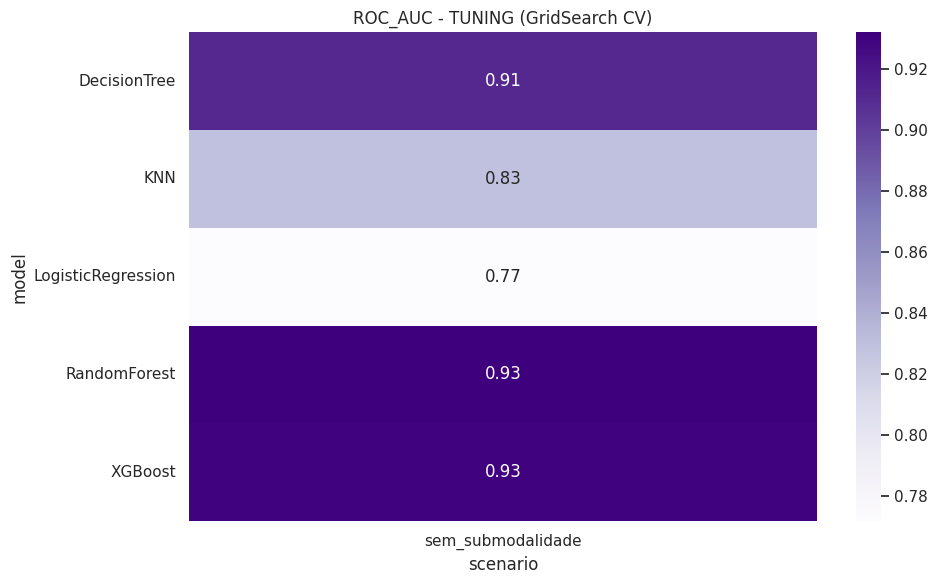

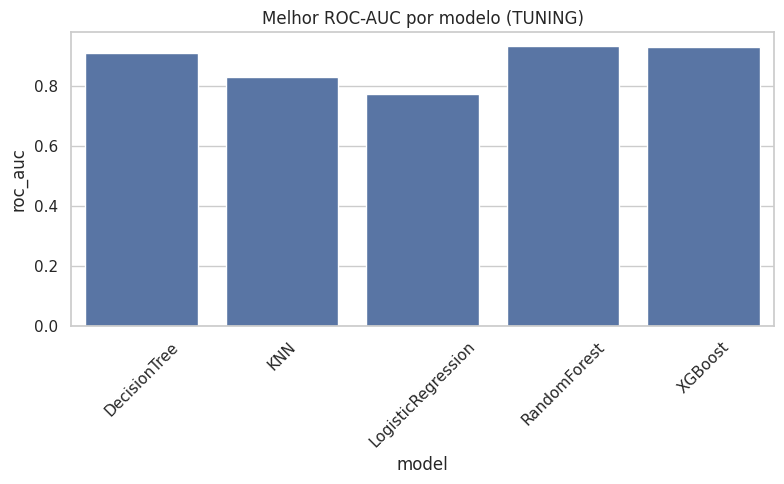

In [81]:
df_tuning = df[df["phase"] == "tuning_cv"].copy()

def plot_heatmap_tuning(metric, cmap):
    pivot = df_tuning.pivot_table(
        index="model",
        columns="scenario",
        values=metric
    )

    plt.figure(figsize=(10,6))
    sns.heatmap(pivot, annot=True, cmap=cmap)
    plt.title(f"{metric.upper()} - TUNING (GridSearch CV)")
    plt.tight_layout()
    plt.show()

plot_heatmap_tuning("roc_auc", "Purples")

#? RANKING TUNING
df_best_tuning = df_tuning.loc[
    df_tuning.groupby("model")["roc_auc"].idxmax()
]

plt.figure(figsize=(8,5))
sns.barplot(data=df_best_tuning, x="model", y="roc_auc")
plt.title("Melhor ROC-AUC por modelo (TUNING)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### GRIDSEARCH - Teste

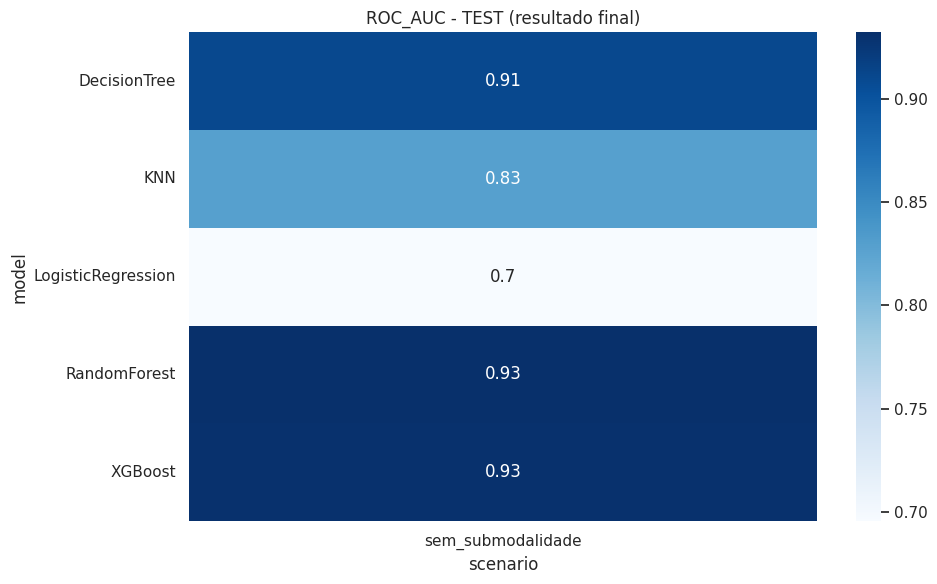

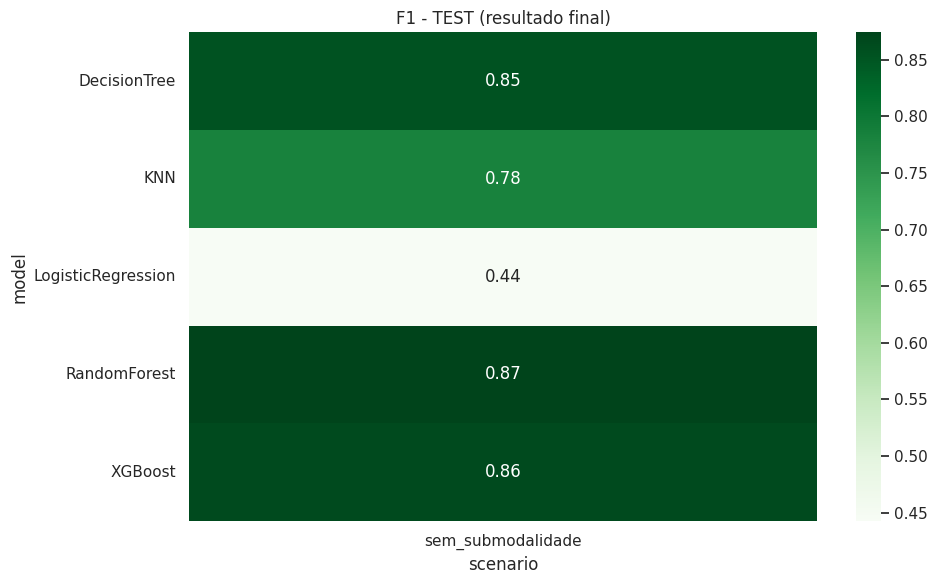

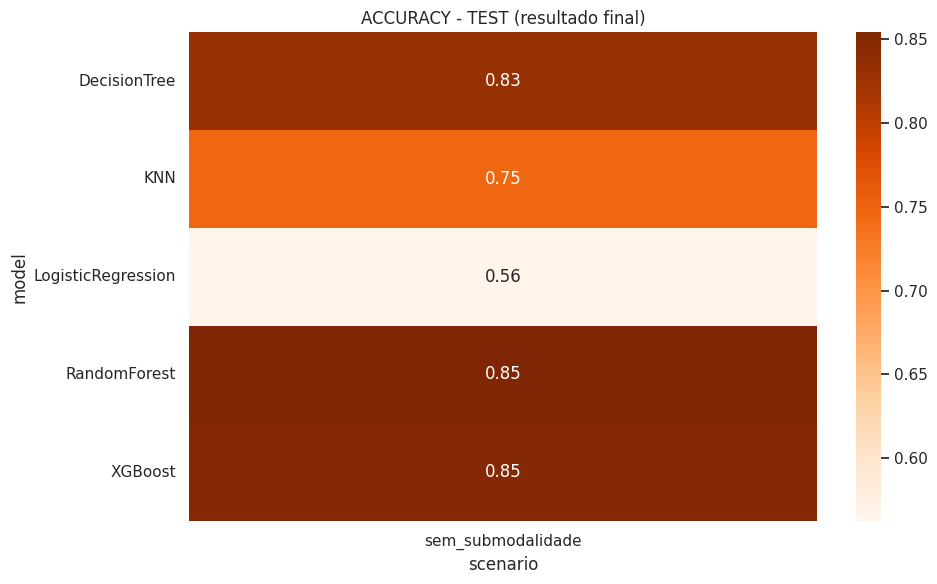

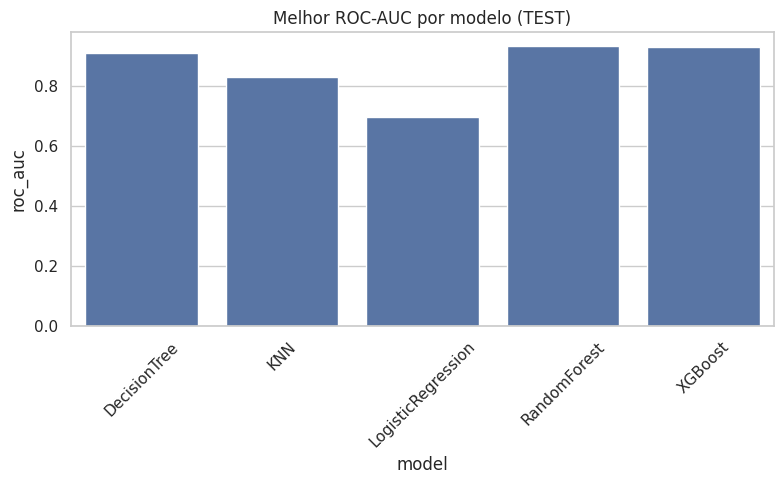

In [82]:
df_test = df[df["phase"] == "test"].copy()

def plot_heatmap_test(metric, cmap):
    pivot = df_test.pivot_table(
        index="model",
        columns="scenario",
        values=metric
    )

    plt.figure(figsize=(10,6))
    sns.heatmap(pivot, annot=True, cmap=cmap)
    plt.title(f"{metric.upper()} - TEST (resultado final)")
    plt.tight_layout()
    plt.show()

plot_heatmap_test("roc_auc", "Blues")
plot_heatmap_test("f1", "Greens")
plot_heatmap_test("accuracy", "Oranges")


#? RANKING TEST
df_best_test = df_test.loc[
    df_test.groupby("model")["roc_auc"].idxmax()
]

plt.figure(figsize=(8,5))
sns.barplot(data=df_best_test, x="model", y="roc_auc")
plt.title("Melhor ROC-AUC por modelo (TEST)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()